# Predicting Student Health Risk - Exploratory Data Analysis

## Objective
This notebook performs an in-depth exploratory data analysis (EDA) of the Student Health Risk dataset.

The goals are to:
- Understand the dataset structure
- Analyze missing values
- Explore feature distributions
- Study relationships between health condition and lifestyle factors
- Identify important predictors for machine learning models

# Contents

1. Introduction

2. Data Overview

3. Missing Values

4. Univariate Analysis

5. Bivariate Analysis

6. Key Findings

7. Next Steps

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ks_2samp

In [ ]:
df = pd.read_csv('../data/train.csv')
df.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [ ]:
test =pd.read_csv('../data/test.csv')

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 690088
Columns : 15


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [7]:
summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing": df.isnull().sum(),
    "Unique": df.nunique()
})

summary

,Data Type,Missing,Unique
id,int64,0,690088
health_condition,object,0,3
sleep_duration,float64,75999,701
heart_rate,float64,7833,537
bmi,float64,13898,1596
calorie_expenditure,float64,52853,2101
step_count,float64,13916,12807
exercise_duration,float64,6901,856
water_intake,float64,43477,400
diet_type,object,6901,3


In [8]:
# Missing Values Report
missing_report = pd.DataFrame({
    "Column Name": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2).values
})

# Sort by highest missing percentage
missing_report = missing_report.sort_values(
    by="Missing Percentage",
    ascending=False
).reset_index(drop=True)

print(missing_report)

                Column Name  Missing Values  Missing Percentage
0              stress_level           82811               12.00
1            sleep_duration           75999               11.01
2             sleep_quality           58331                8.45
3       calorie_expenditure           52853                7.66
4              water_intake           43477                6.30
5   physical_activity_level           36621                5.31
6           smoking_alcohol           28582                4.14
7                    gender           21373                3.10
8                step_count           13916                2.02
9                       bmi           13898                2.01
10               heart_rate            7833                1.14
11                diet_type            6901                1.00
12        exercise_duration            6901                1.00
13                       id               0                0.00
14         health_condition             

<Axes: >

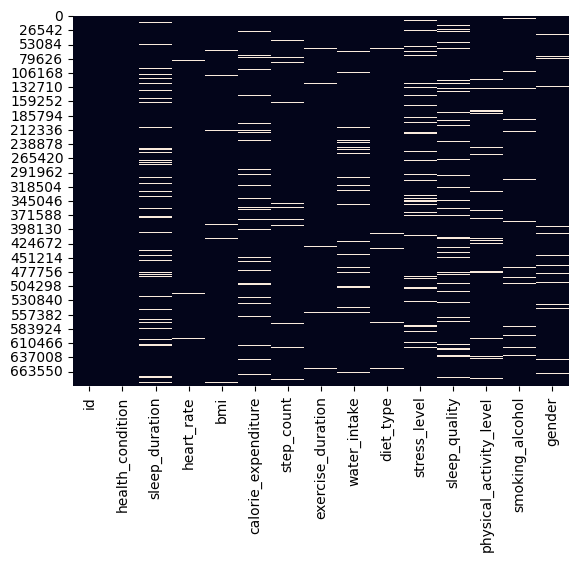

In [9]:
sns.heatmap(df.isnull(), cbar=False)

- The dataset contains missing values in 12 out of 15 features, while id and health_condition have no missing values.
- The highest percentage of missing values is in stress_level (12.00%), followed by sleep_duration (11.01%) and sleep_quality (8.45%).
- Most features have less than 10% missing values, indicating that appropriate imputation techniques can be applied without significant data loss.

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,id,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


<Axes: >

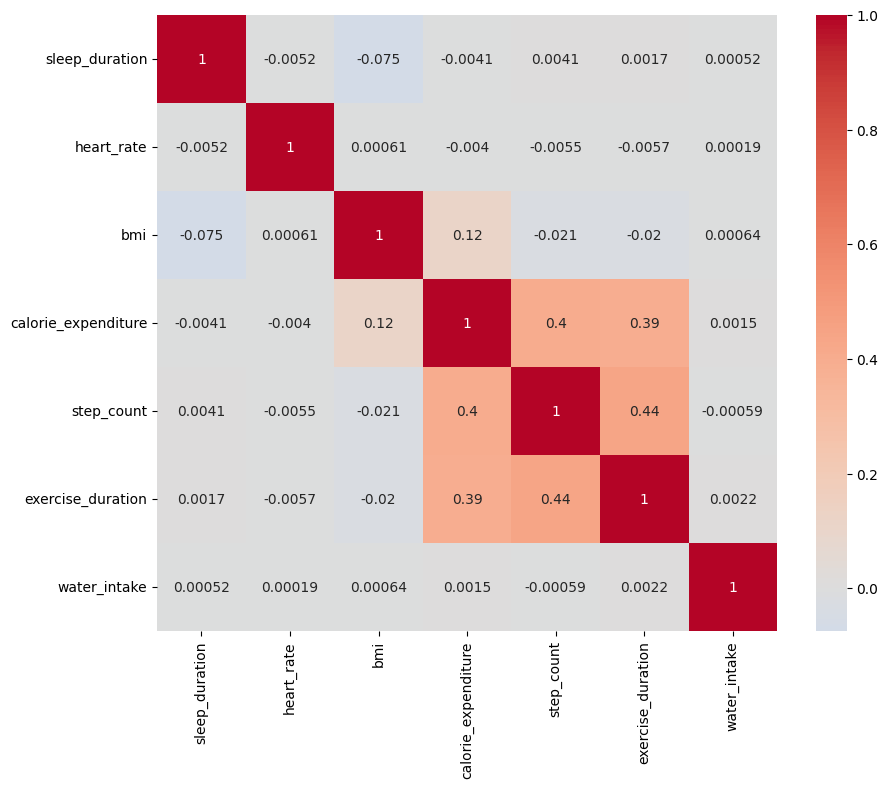

In [12]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns= ['id']).corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            center=0)

In [13]:
from sklearn.preprocessing import LabelEncoder

temp = df.copy()

temp["health_condition"] = LabelEncoder().fit_transform(temp["health_condition"])

<Axes: >

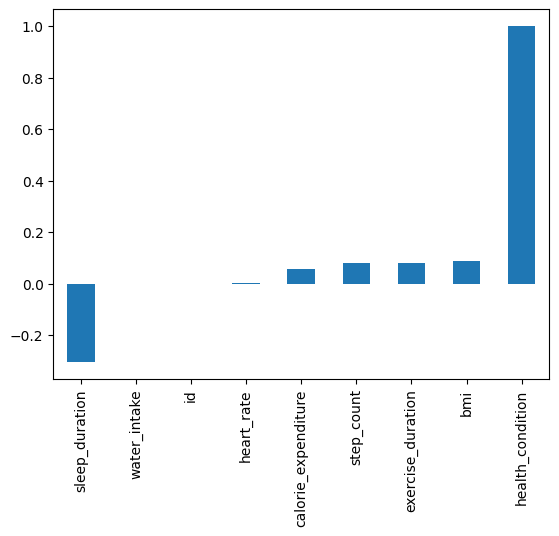

In [14]:
corr = temp.corr(numeric_only=True)["health_condition"].sort_values()
corr.plot(kind= 'bar')

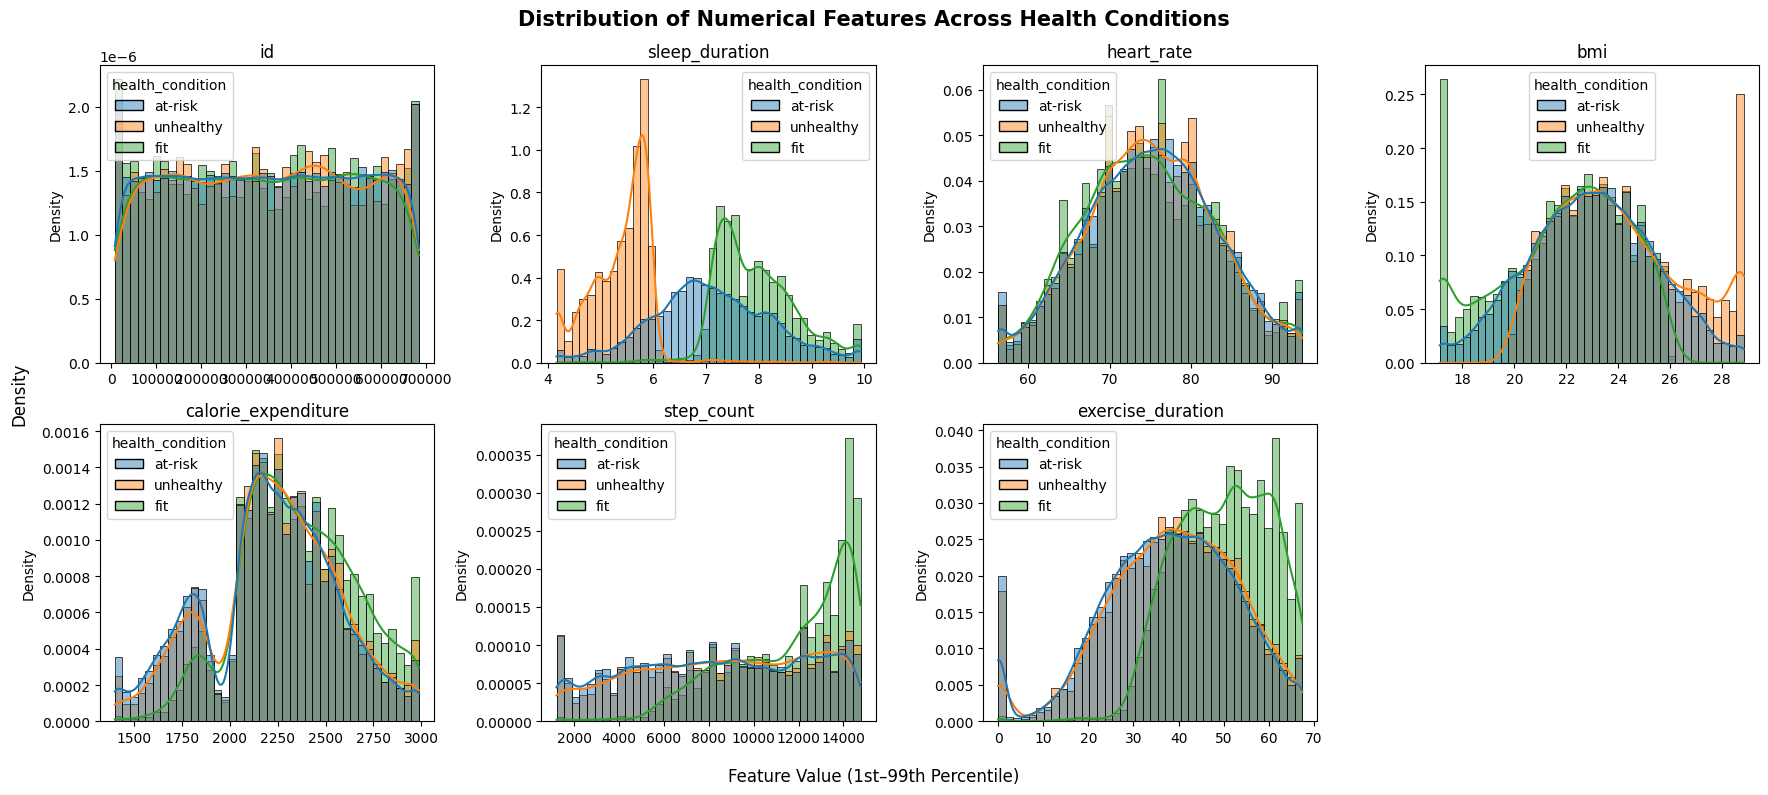

In [15]:
num_cols = df.select_dtypes(exclude = 'O').columns.tolist()

sample_df = df.sample(80000, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    lower = sample_df[col].quantile(0.01)
    upper = sample_df[col].quantile(0.99)

    sns.histplot(data=sample_df.assign(    clipped=sample_df[col].clip(lower, upper)),x="clipped",
                hue="health_condition",bins=40,stat="density",kde= True,common_norm=False,alpha=0.45,ax=axes[i])

    axes[i].set_title(col)
    axes[i].set_xlabel("")

fig.delaxes(axes[-1])

plt.suptitle(
    "Distribution of Numerical Features Across Health Conditions",
    fontsize=15,
    fontweight="bold"
)

fig.supxlabel("Feature Value (1st–99th Percentile)")
fig.supylabel("Density")

plt.tight_layout()
plt.show()

The numerical feature distributions reveal clear differences across the three health conditions. Sleep duration exhibit noticeable separation between the classes. Exercise duration and step count also exhibit some separation between the classes, indicating that these three variables are likely to be strong predictors of student health. In contrast, heart rate and water intake show substantial overlap across the categories, suggesting comparatively lower discriminative power. Overall, the plots provide useful insights for identifying important features and designing meaningful feature engineering strategies.

In [16]:
df.shape[0]

690088

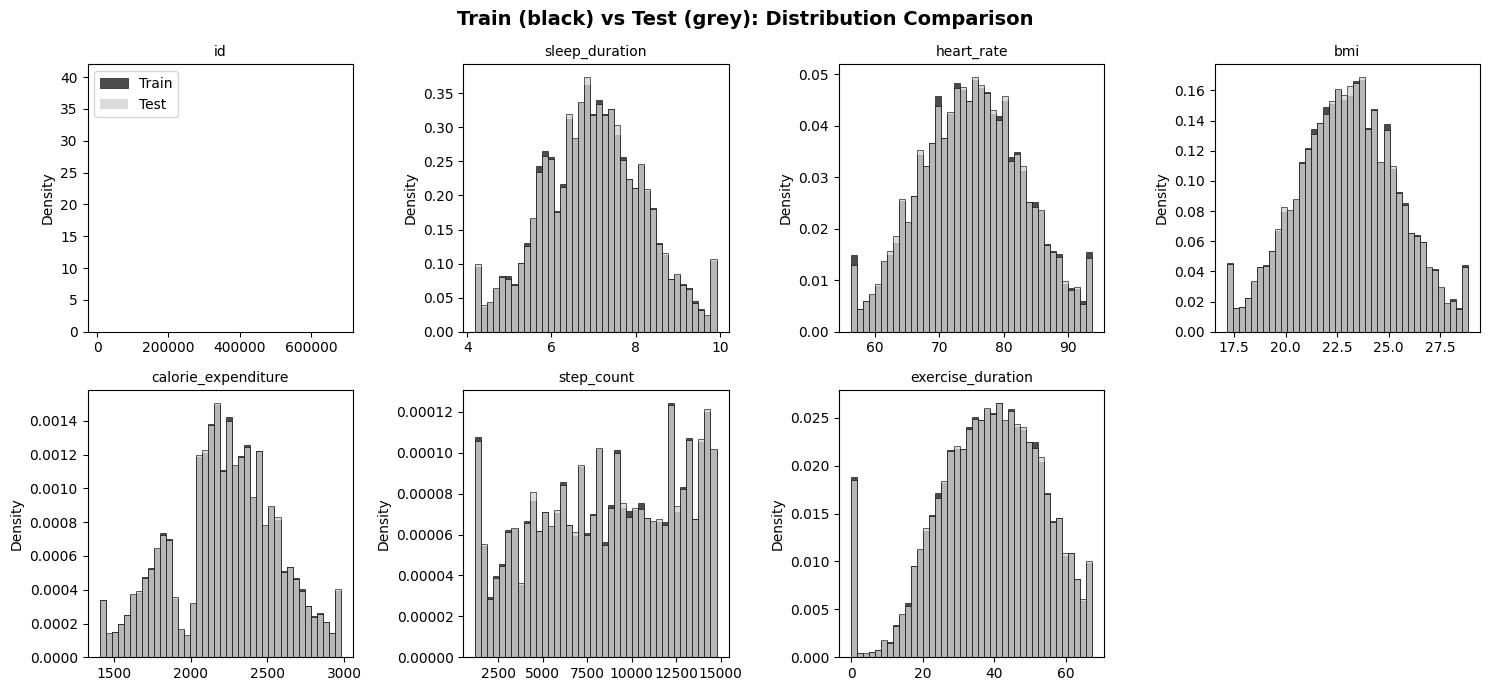

In [17]:
# Sample data for faster plotting
train_sample = df.sample(df.shape[0]//2, random_state=42)
test_sample = test.sample(test.shape[0]//2, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):

    # Clip extreme values (1st-99th percentile)
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)

    train_data = train_sample[col].clip(lower, upper)
    test_data = test_sample[col].clip(lower, upper)

    sns.histplot(train_data,bins=40,stat="density",color="black",alpha=0.7,label="Train",ax=axes[i])

    sns.histplot(test_data,bins=40,stat="density",color="lightgrey",alpha=0.8,label="Test",ax=axes[i])

    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Density")

# Hide unused subplot
fig.delaxes(axes[-1])

# Show legend only once
axes[0].legend()

plt.suptitle(
    "Train (black) vs Test (grey): Distribution Comparison",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

The distributions of all numerical features are highly consistent between the training and test datasets. No noticeable distribution shift or sampling bias is observed, indicating that both datasets originate from the same underlying distribution. This suggests that models trained on the training data are expected to generalize well to the test set without requiring additional drift correction or domain adaptation.

In [18]:
results = []

for col in num_cols:
    ks_stat, p_value = ks_2samp(df[col].dropna(),
                                test[col].dropna())

    results.append({
        "Feature": col,
        "KS Statistic": round(ks_stat, 4),
        "P-value": round(p_value, 6)
    })

ks_df = pd.DataFrame(results)
ks_df = ks_df[ks_df.Feature != 'id']
ks_df.sort_values("KS Statistic", ascending=False)

,Feature,KS Statistic,P-value
7,water_intake,0.0034,0.025299
5,step_count,0.0023,0.213390
2,heart_rate,0.0020,0.386290
1,sleep_duration,0.0018,0.594842
4,calorie_expenditure,0.0017,0.652375
6,exercise_duration,0.0016,0.633504
3,bmi,0.0011,0.959105



The Kolmogorov–Smirnov (KS) statistics for all numerical features are extremely small (all below 0.005), indicating negligible distribution differences between the training and test datasets. Although the p-value for water_intake is statistically significant due to the very large sample size, its KS statistic remains extremely low (0.0034), implying that the practical difference is insignificant. Overall, both the visual inspection and the KS statistics confirm the absence of meaningful dataset drift, making the train–test split suitable for reliable model development and evaluation.

## Exploritary Data Analysis

### Univariate Analysis

Sleep Duration

In [19]:
def num_col(col):
    fig,ax = plt.subplots(nrows=1,ncols=2,figsize = (8,5))
    sns.kdeplot(data = df, x= col,fill=True,ax = ax[0])
    sns.boxplot(data = df, x= col,ax = ax[1])
    plt.tight_layout()
    plt.show()


In [20]:
def calculate_outliers(col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)]

    count = outliers.shape[0]
    percentage = (count / len(df)) * 100

    return count, round(percentage, 2)


In [21]:
df['sleep_duration'].describe()

count    614089.000000
mean          6.992597
std           1.215407
min           3.000000
25%           6.160000
50%           6.990000
75%           7.810000
max          10.000000
Name: sleep_duration, dtype: float64

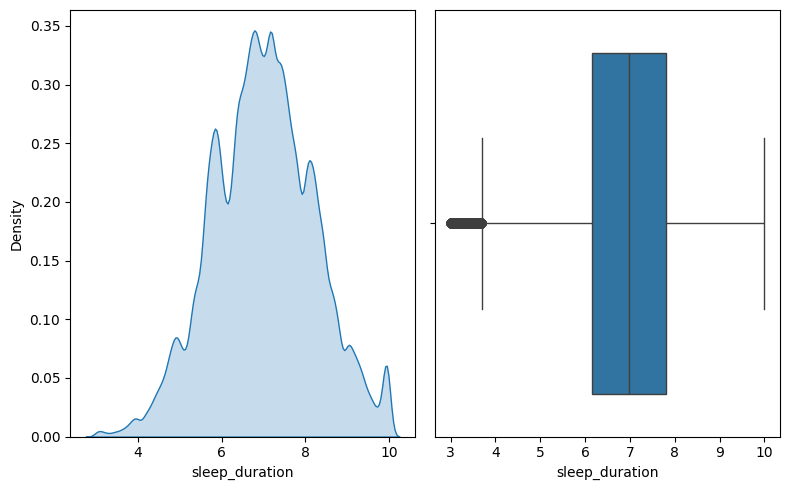

In [22]:
num_col('sleep_duration')

In [23]:
calculate_outliers('sleep_duration')

(2020, 0.29)

In [24]:
# Skewness and Kurtosis
skewness = df['sleep_duration'].skew()
kurtosis = df['sleep_duration'].kurt()

print(skewness,kurtosis)

-0.00823233899896683 -0.11445104707915732


- The distribution of sleep_duration is approximately symmetric, as the skewness value (-0.008) is very close to zero, indicating no significant left or right skew.
- The majority of sleep duration values lie between approximately 6 and 8 hours, with the median close to 7 hours, suggesting that most individuals have a healthy sleep duration.
- The box plot shows a few potential outliers on the lower end (around 3–4 hours), indicating that a small number of individuals report significantly shorter sleep durations.
- The kurtosis value (-0.114) indicates a slightly platykurtic distribution, meaning the data has a flatter peak and slightly lighter tails than a normal distribution.

In [25]:
df.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

Health Condition

In [26]:
df["health_condition"].value_counts(normalize=True)*100

health_condition
at-risk      85.867455
unhealthy     8.364730
fit           5.767815
Name: proportion, dtype: float64

<Axes: xlabel='health_condition'>

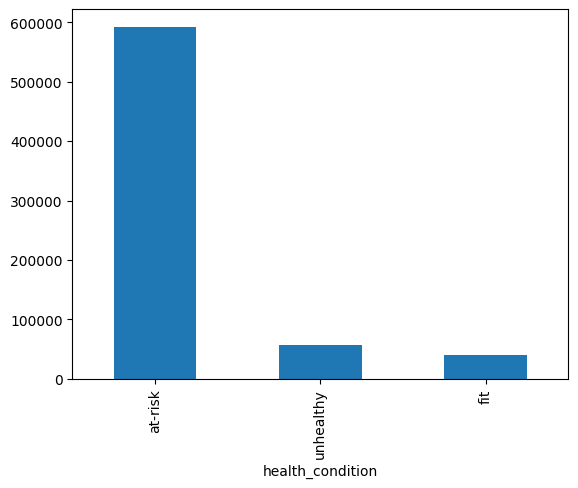

In [27]:
df['health_condition'].value_counts().plot(kind = 'bar')

- According to the above plot we can observe that most of the students health condition is at risk

Heart Rate

In [28]:
df['heart_rate'].describe()

count    682255.000000
mean         75.096504
std           8.175106
min          50.000000
25%          69.400000
50%          75.100000
75%          80.700000
max         107.700000
Name: heart_rate, dtype: float64

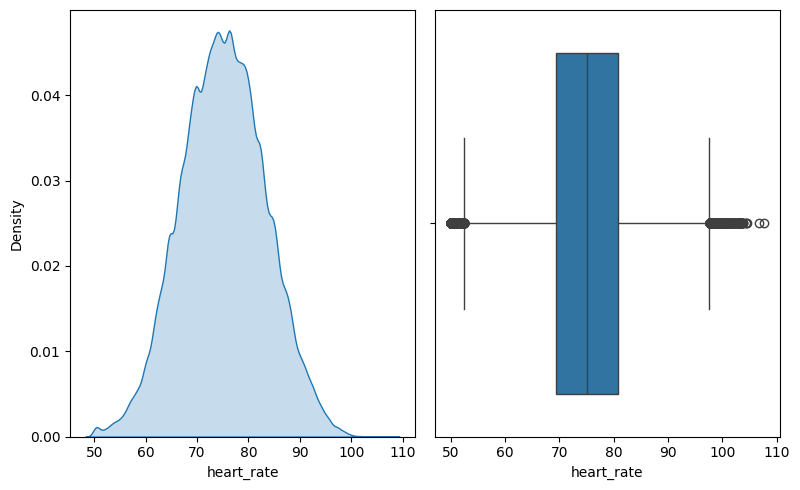

In [29]:
num_col('heart_rate')

In [30]:
# Skewness and Kurtosis
skewness = df['heart_rate'].skew()
kurtosis = df['heart_rate'].kurt()

print(skewness,kurtosis)

0.0004382013061367681 -0.18670818738750317


- The heart_rate distribution is approximately symmetric and bell-shaped, with a skewness value of 0.0023, indicating almost no skewness.
- Most heart rate values fall between 70 and 80 bpm, with the median close to 75 bpm, suggesting that the majority of individuals have a normal resting heart rate.
- The box plot reveals a few outliers at both the lower and upper ends of the distribution, but the overall spread is consistent and the feature appears suitable for further statistical analysis and modeling.

BMI

In [31]:
df['bmi'].describe()

count    676190.000000
mean         22.984925
std           2.481787
min          16.000000
25%          21.320000
50%          22.990000
75%          24.660000
max          34.820000
Name: bmi, dtype: float64

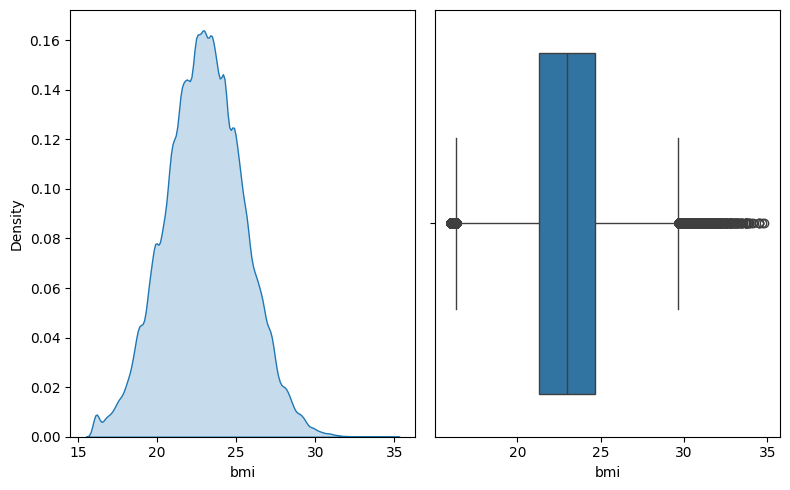

In [32]:
num_col('bmi')

In [33]:
calculate_outliers('bmi')

(5352, 0.78)

In [34]:
# Skewness and Kurtosis
skewness = df['sleep_duration'].skew()
kurtosis = df['sleep_duration'].kurt()

print(skewness,kurtosis)

-0.00823233899896683 -0.11445104707915732


- The bmi distribution is approximately bell-shaped and nearly symmetric, with most values concentrated between 21 and 25, indicating a generally healthy BMI range for the majority of individuals.
- The box plot shows several outliers on the higher end (BMI > 30), suggesting the presence of individuals with obesity, while only a few observations lie at the lower end.
- Overall, the bmi feature exhibits a moderate spread with a few high-value outliers but follows an approximately normal distribution, making it suitable for further analysis after considering outlier treatment if necessary.

Calorie Expenditure

In [35]:
df['calorie_expenditure'].describe()

count    637235.000000
mean       2226.084931
std         347.532098
min        1200.000000
25%        2053.000000
50%        2241.000000
75%        2456.000000
max        3580.000000
Name: calorie_expenditure, dtype: float64

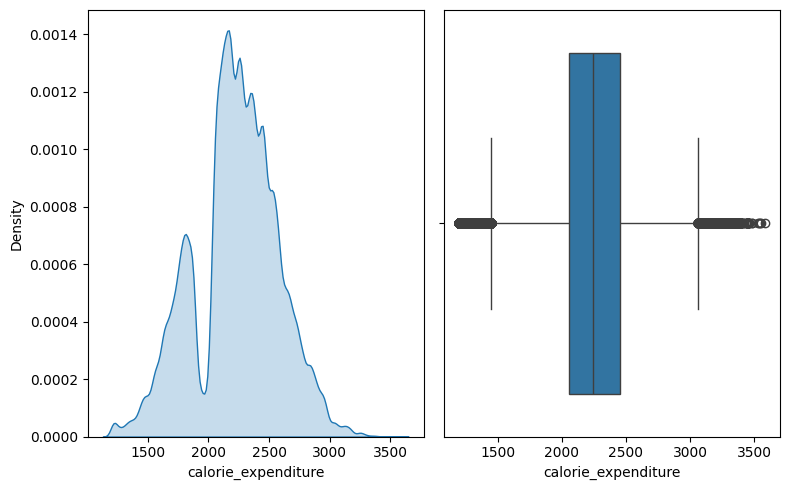

In [36]:
num_col('calorie_expenditure')

In [37]:
calculate_outliers('calorie_expenditure')

(12831, 1.86)

In [38]:
# Skewness and Kurtosis
skewness = df['calorie_expenditure'].skew()
kurtosis = df['calorie_expenditure'].kurt()

print(skewness,kurtosis)

-0.1839399892368627 -0.06262850531136799


- The calorie_expenditure feature exhibits a bimodal distribution, with peaks around 1800 and 2200–2300 calories, indicating the presence of two distinct groups in the dataset.
- The distribution is not normally distributed despite having a skewness value close to zero, highlighting that skewness alone does not capture the multimodal nature of the data.
- Most individuals have a calorie expenditure between approximately 2,000 and 2,500 calories, with the highest density centered around 2,200–2,400 calories.
- The box plot reveals a few outliers on both the lower and upper ends of the distribution, but the majority of observations are concentrated within a relatively narrow range, making the feature suitable for further analysis.

In [39]:
df.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

Step Count

In [40]:
df['step_count'].describe()

count    676172.000000
mean       8615.953050
std        3929.399831
min        1002.000000
25%        5389.000000
50%        8856.000000
75%       12114.000000
max       14999.000000
Name: step_count, dtype: float64

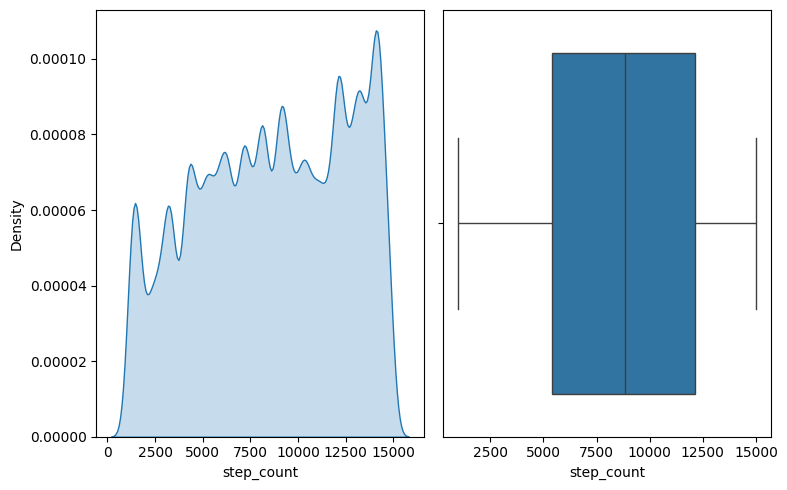

In [41]:
num_col('step_count')

In [42]:
calculate_outliers('step_count')

(0, 0.0)

In [43]:
# Skewness and Kurtosis
skewness = df['step_count'].skew()
kurtosis = df['step_count'].kurt()

print(skewness,kurtosis)

-0.18023843603832704 -1.1148790599883853


- The step_count distribution is not normally distributed and exhibits multiple peaks, suggesting the presence of different activity-level groups within the dataset.
- Although the skewness value (-0.184) indicates only a slight negative skew, the KDE plot reveals that the distribution is not perfectly symmetric and is better described as multimodal.
- The box plot shows no significant outliers, indicating that most step count values fall within a reasonable range despite the irregular distribution shape.

Exercise Duration

In [44]:
df['exercise_duration'].describe()

count    683187.000000
mean         38.751456
std          14.742189
min           0.000000
25%          29.200000
50%          39.400000
75%          49.400000
max          99.800000
Name: exercise_duration, dtype: float64

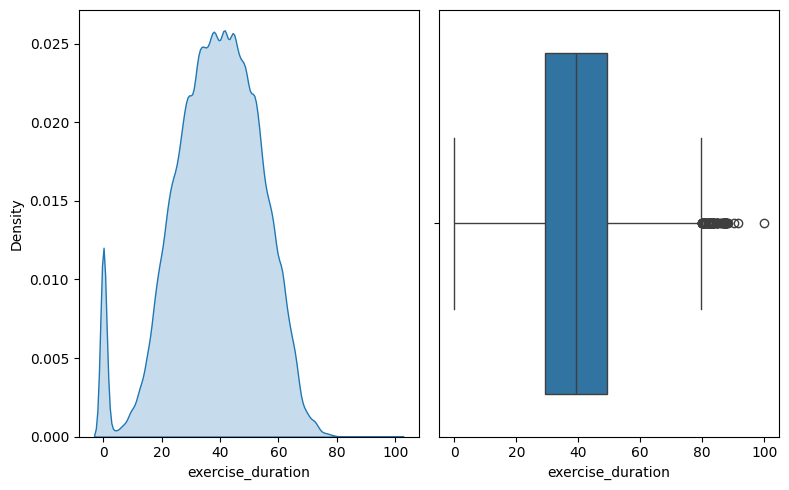

In [45]:
num_col('exercise_duration')

In [46]:
calculate_outliers('exercise_duration')

(104, 0.02)

In [47]:
# Skewness and Kurtosis
skewness = df['exercise_duration'].skew()
kurtosis = df['exercise_duration'].kurt()

print(skewness,kurtosis)

-0.3746098024470961 0.03465360952534846


In [48]:
pd.crosstab(df['exercise_duration'] == 0,
            df['health_condition'],
            normalize='index') * 100

health_condition,at-risk,fit,unhealthy
exercise_duration,,,
False,85.726926,5.902639,8.370435
True,91.607544,0.260748,8.131708


- The spike at 0 minutes represents a meaningful subgroup rather than erroneous data, indicating individuals who report no exercise.
- Among individuals with zero exercise duration, 91.56% belong to the at-risk category, while only 0.16% are classified as fit, suggesting a strong association between lack of exercise and poor health.
- Since the zero values have clear predictive significance, they should be retained during preprocessing rather than treated as outliers or removed.

Water Intake

In [49]:
df['water_intake'].describe()

count    646611.000000
mean          2.188542
std           0.518489
min           0.500000
25%           1.840000
50%           2.170000
75%           2.500000
max           4.720000
Name: water_intake, dtype: float64

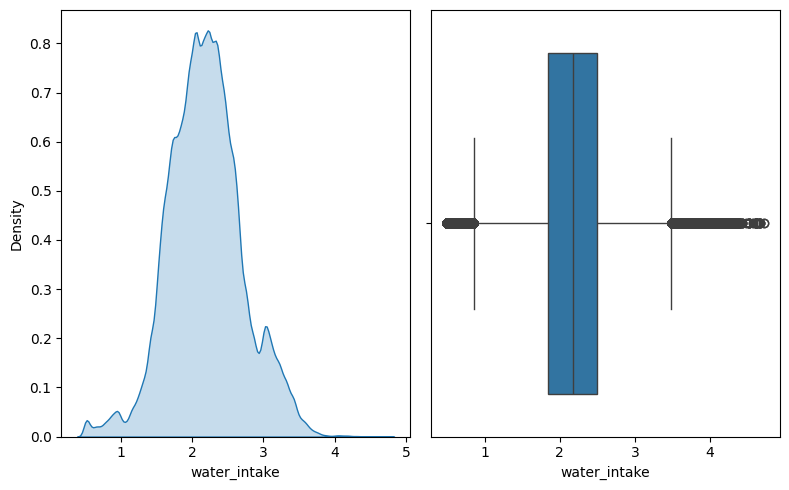

In [50]:
num_col('water_intake')

In [51]:
calculate_outliers('water_intake')

(11388, 1.65)

In [52]:
# Skewness and Kurtosis
skewness = df['water_intake'].skew()
kurtosis = df['water_intake'].kurt()

print(skewness,kurtosis)

0.10996029570066149 0.4942917163887204


- The water_intake distribution is approximately bell-shaped with a slight positive skew (skewness = 0.111), indicating a marginally longer tail toward higher water intake values.
- Most individuals consume between 1.8 and 2.6 liters of water per day, with the highest concentration of observations around 2.2 liters.
- The box plot shows a few outliers at both the lower and upper ends of the distribution, particularly above 3.5 liters, while the majority of observations are concentrated within a relatively narrow range.

In [53]:
df.columns

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='object')

Diet Type

<Axes: xlabel='diet_type'>

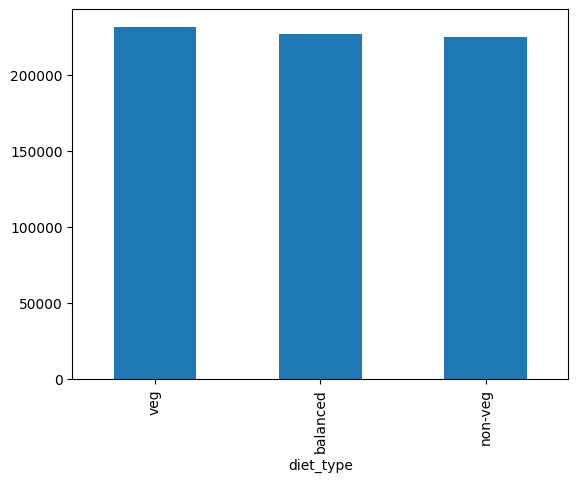

In [54]:
df['diet_type'].value_counts().plot(kind = 'bar')

The diet_type feature consists of three categories: veg, balanced, and non-veg. The balanced category represents individuals following a nutritionally balanced diet containing appropriate proportions of essential nutrients, while veg and non-veg represent vegetarian and non-vegetarian dietary patterns, respectively.

Stress Level

<Axes: xlabel='stress_level'>

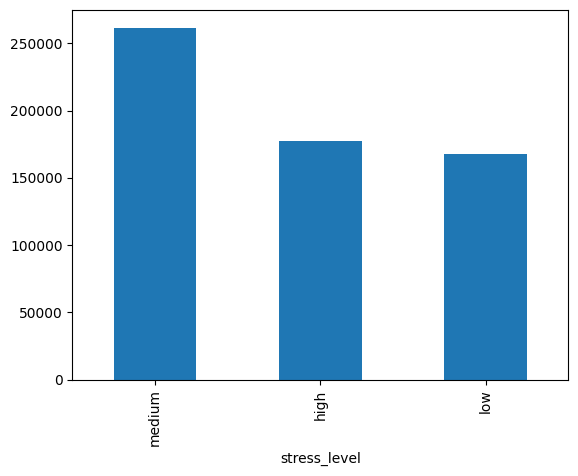

In [55]:
df['stress_level'].value_counts().plot(kind = 'bar')

In [56]:
(df['stress_level'].value_counts(normalize=True) * 100).round(2)

stress_level
medium    43.11
high      29.27
low       27.62
Name: proportion, dtype: float64

The diet_type feature consists of three categories: medium, high and low. According to the dataset almost 43.08% of student have falls under the category of medium, 29.27% of students have falls under the category of high and 27.65% students have falls under the category of low.

Sleep quality

<Axes: xlabel='sleep_quality'>

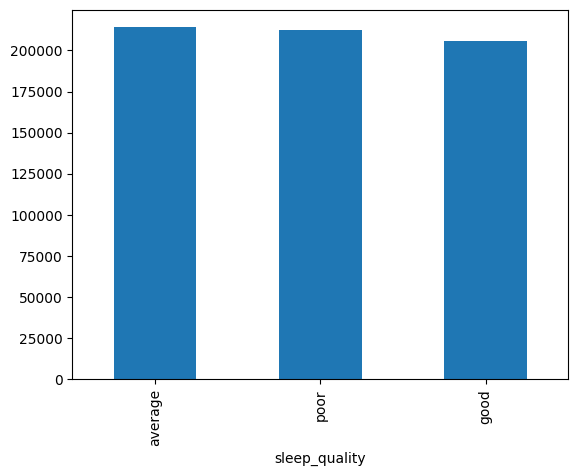

In [57]:
df['sleep_quality'].value_counts().plot(kind = 'bar')

Physical Activity Level

<Axes: xlabel='physical_activity_level'>

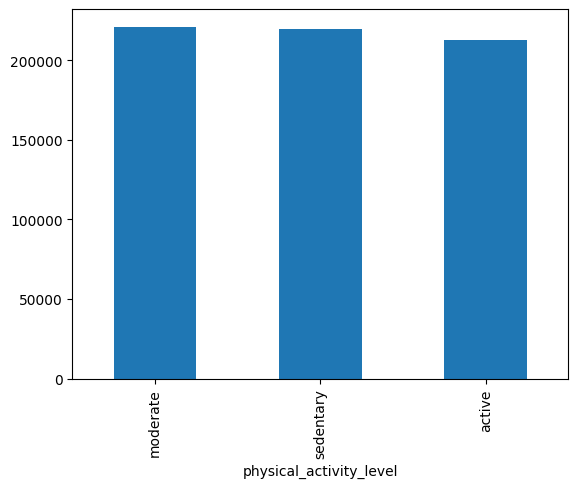

In [58]:
df['physical_activity_level'].value_counts().plot(kind = 'bar')

Smoking Alcohol

<Axes: xlabel='smoking_alcohol'>

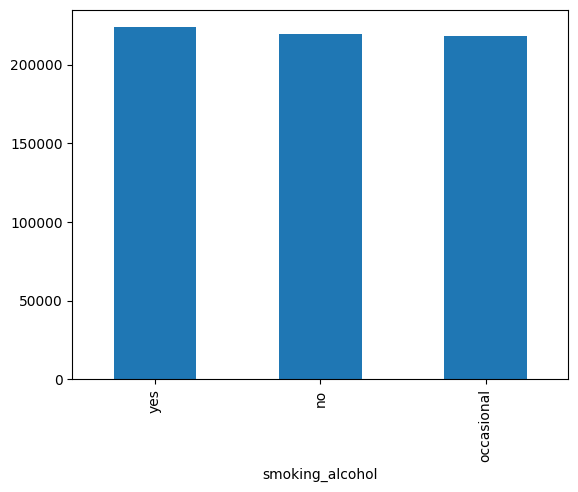

In [59]:
df['smoking_alcohol'].value_counts().plot(kind = 'bar')

Gender

<Axes: xlabel='gender'>

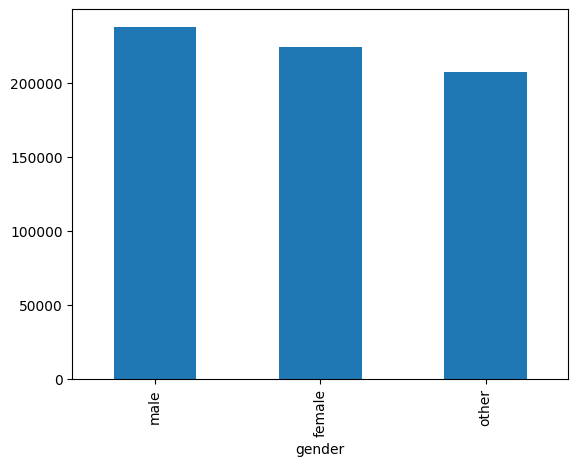

In [60]:
df['gender'].value_counts().plot(kind = 'bar')

In [61]:
# Outlier Summary Table
num_cols = df.select_dtypes(exclude='O').drop(columns=['id']).columns.tolist()

rows = []

for col in num_cols:
    count, percentage = calculate_outliers(col)
    rows.append([col, count, percentage])

outlier_summary = pd.DataFrame(
    rows,
    columns=['Feature', 'Outlier Count', 'Outlier Percentage']
)

outlier_summary

,Feature,Outlier Count,Outlier Percentage
0,sleep_duration,2020,0.29
1,heart_rate,2825,0.41
2,bmi,5352,0.78
3,calorie_expenditure,12831,1.86
4,step_count,0,0.00
5,exercise_duration,104,0.02
6,water_intake,11388,1.65


## Bivariate Analysis

Health Condition vs Sleep Duration

In [62]:
def num_vs_cat(cat_col, num_col):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

    sns.barplot(data=df, x=cat_col, y=num_col, ax=ax[0])
    ax[0].set_title(f'Bar Plot: {num_col}')

    sns.violinplot(data=df,  x=cat_col, y=num_col, ax=ax[1])
    ax[1].set_title(f'Violin Plot: {num_col}')

    sns.boxplot(data=df, x=cat_col, y=num_col,  ax=ax[2])
    ax[2].set_title(f'Box Plot: {num_col}')

    plt.tight_layout()
    plt.show()

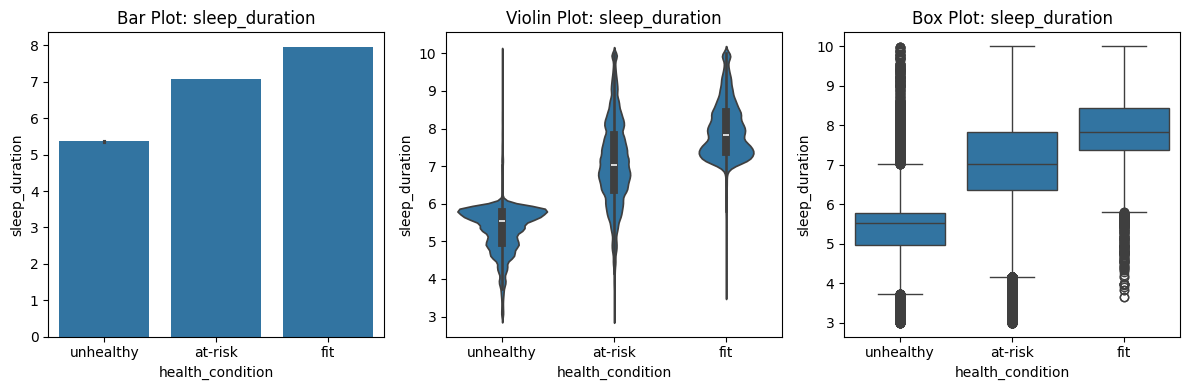

In [63]:
num_vs_cat('health_condition','sleep_duration')

- Individuals in the fit category have the highest average sleep duration (around 8 hours), followed by the at-risk group (around 7 hours), while the unhealthy group has the lowest average sleep duration (around 5.5 hours).
- The violin plot indicates that the fit group has sleep durations concentrated between approximately 7.5 and 8.5 hours, whereas the unhealthy group is concentrated around 5–6 hours.
- The box plots show a clear upward shift in the median sleep duration from unhealthy to at-risk to fit, suggesting a positive association between longer sleep duration and better health condition.
- Although a few outliers exist in each health category, the overall distributions have relatively little overlap, indicating that sleep_duration is likely to be a strong predictor of health_condition.

Health Condition vs Heart Rate

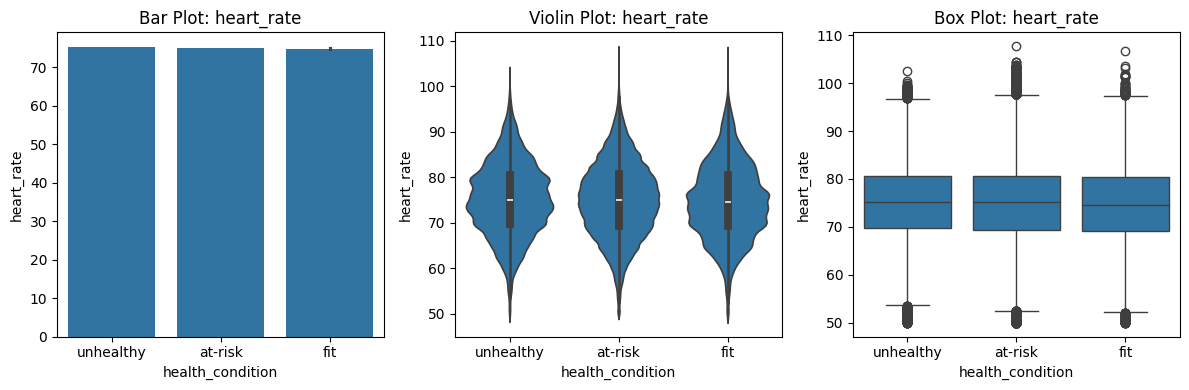

In [64]:
num_vs_cat('health_condition','heart_rate')

- The average heart rate is nearly identical across all three health conditions (unhealthy, at-risk, and fit), remaining around 75 bpm, indicating that heart rate alone does not clearly differentiate the health categories.
- The violin plots show very similar distributions for all three groups, with most heart rate values concentrated between 70 and 80 bpm and no noticeable shift in the distribution across health conditions.
- The box plots reveal comparable median values and interquartile ranges (IQRs) for all health conditions, suggesting that the variability in heart rate is consistent across the groups.
- All three health categories contain a few high and low outliers; however, the extent of these outliers is similar across the groups, indicating that extreme heart rate values are not specific to any particular health condition.

Health Condition vs BMI


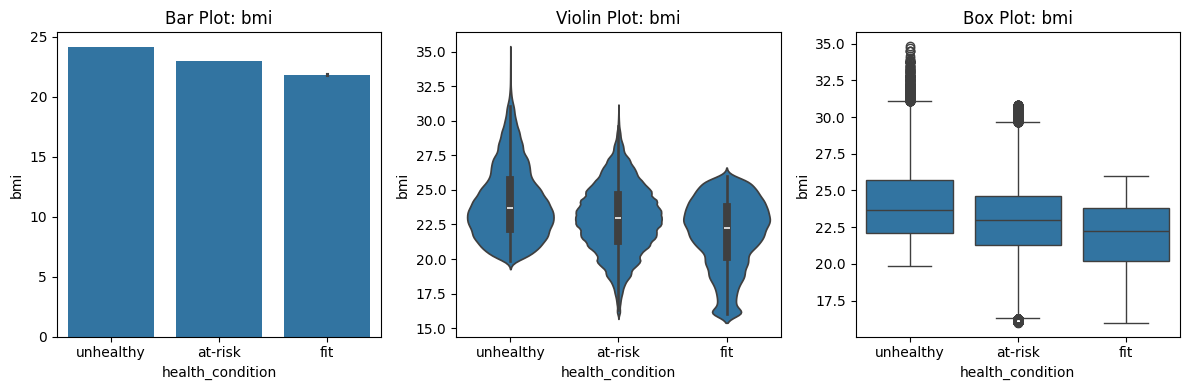

In [65]:
num_vs_cat('health_condition','bmi')

- The average BMI decreases progressively from the unhealthy group to the at-risk group and is lowest in the fit group, indicating an inverse relationship between BMI and overall health condition.
- The box plots show a gradual downward shift in the median BMI from unhealthy to fit, suggesting that individuals in the fit category generally maintain a lower BMI than the other groups.
- The unhealthy group exhibits the highest BMI values and contains several high-end outliers (BMI > 30), whereas such extreme values are much less frequent in the fit group.
- Although the BMI distributions overlap across the three health conditions, the overall trend indicates that lower BMI values are more commonly associated with the fit category, making BMI a potentially informative predictor of health condition.

Health Condition vs Calorie Expenditure


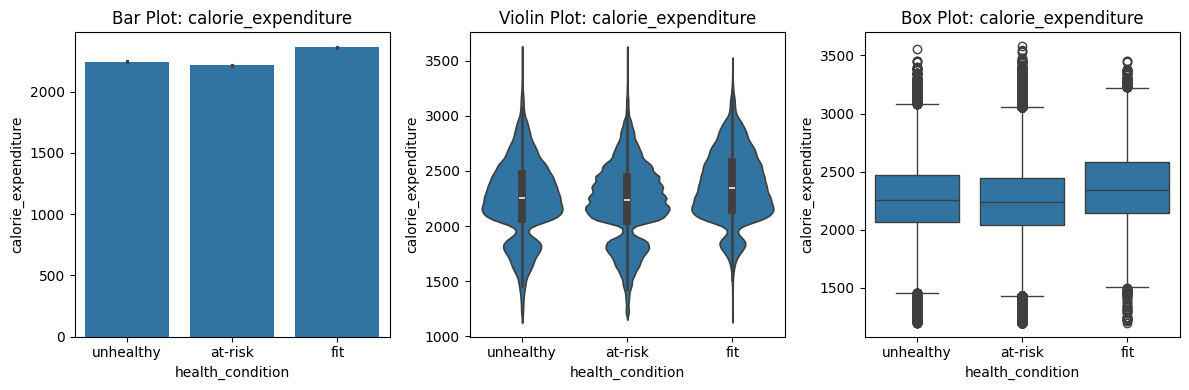

In [66]:
num_vs_cat('health_condition','calorie_expenditure')

- The fit group has the highest average calorie expenditure, followed by the unhealthy and at-risk groups, indicating that healthier individuals tend to burn more calories on average.
- The violin plots show that the fit group has a slightly higher concentration of observations between 2200 and 2600 calories, whereas the other two groups are centered around slightly lower values.
- The box plots reveal a gradual increase in the median calorie expenditure from the at-risk and unhealthy groups to the fit group, suggesting a positive association between calorie expenditure and better health condition.
- Although all three health categories exhibit a similar spread and contain both low and high outliers, the upward shift in the median and mean for the fit group indicates that calorie_expenditure may serve as a useful predictor of health condition.


Health_condition vs Step Count


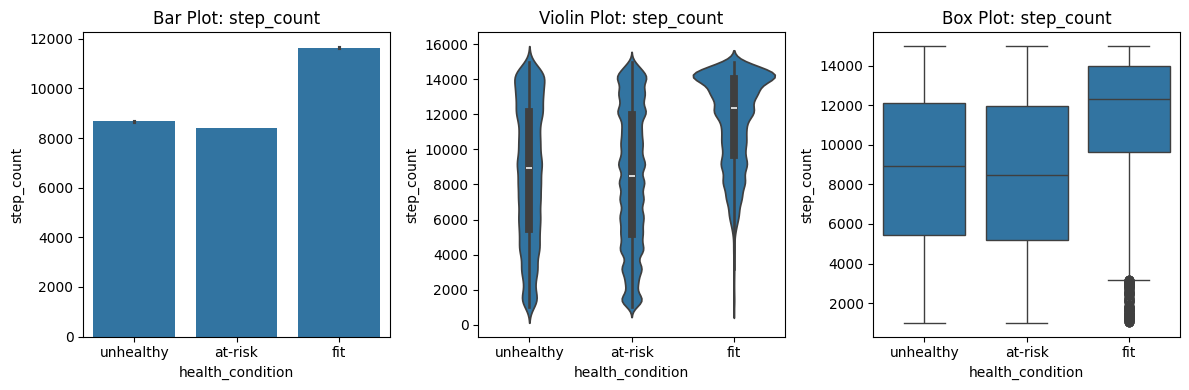

In [67]:
num_vs_cat('health_condition','step_count')

- The fit group has the highest average step count (around 11,700 steps), whereas the unhealthy and at-risk groups have considerably lower and similar average step counts (around 8,500 steps).
- The box plots show a clear upward shift in the median step count for the fit group, indicating that healthier individuals tend to take substantially more daily steps than the other two groups.
- The violin plots reveal that the fit group has a higher concentration of observations between 12,000 and 15,000 steps, while the unhealthy and at-risk groups are more widely distributed across lower step counts.
- Although a few low-step outliers are present in the fit category, the overall distribution is shifted toward higher activity levels, suggesting that step_count is a strong predictor of health_condition.

Health Condition vs Exercise Duration

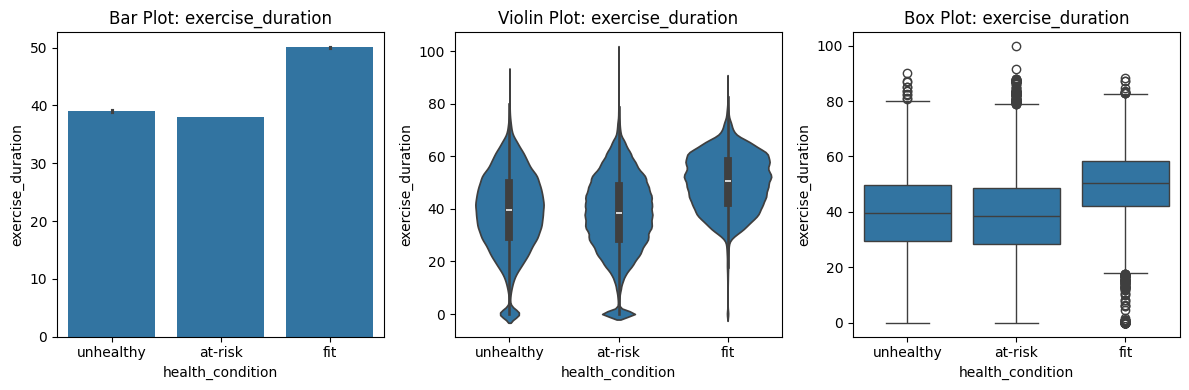

In [68]:
num_vs_cat('health_condition','exercise_duration')

- The fit group has the highest average exercise duration (around 50 minutes), whereas the unhealthy and at-risk groups have similar average exercise durations of approximately 39–40 minutes.
- The box plots show a noticeable upward shift in the median exercise duration for the fit group, indicating that healthier individuals generally spend more time exercising than the other two groups.
- The violin plots reveal that the fit group has a higher concentration of exercise durations between 45 and 60 minutes, while the unhealthy and at-risk groups are primarily concentrated between 30 and 50 minutes.
- Although a few low- and high-duration outliers are present across all health categories, the overall distribution for the fit group is shifted toward longer exercise durations, suggesting that exercise_duration is a useful predictor of health condition.

Health Condition vs Water Intake

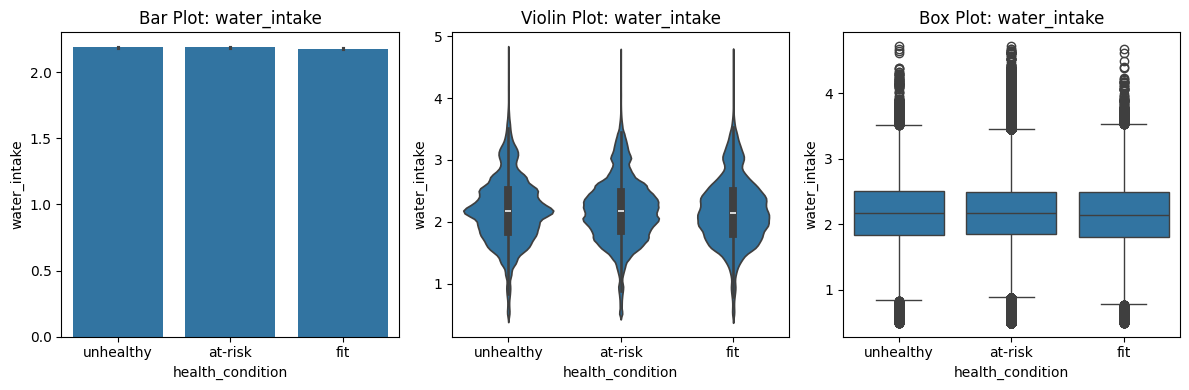

In [69]:
num_vs_cat('health_condition','water_intake')

Unlike features such as sleep_duration, step_count, and exercise_duration, water_intake does not show a clear association with health_condition and is unlikely to be a strong standalone predictor.

Health Condition vs Diet Type

In [70]:
def cat_vs_cat(col1, col2):
    ct = pd.crosstab(df[col1], df[col2], normalize='index') * 100

    plt.figure(figsize=(12, 5))
    sns.heatmap(ct, annot=True, fmt='.1f', cmap='Blues')
    plt.show()

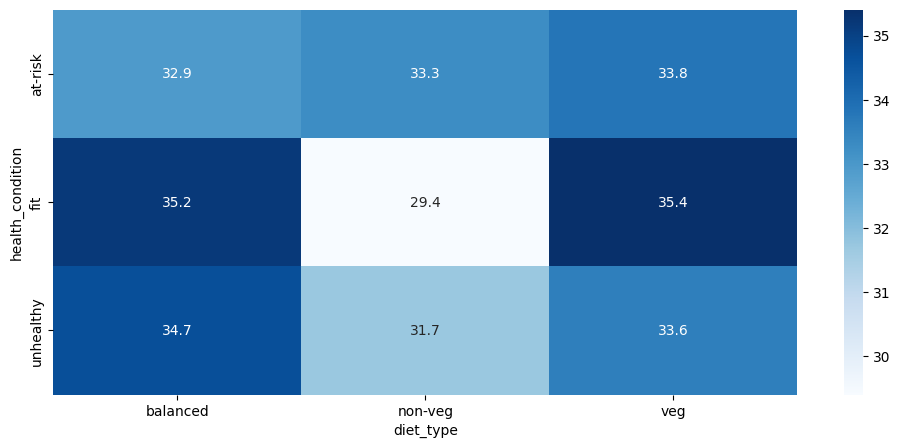

In [71]:
cat_vs_cat('health_condition','diet_type')

- The distribution of diet types is fairly consistent across all health conditions, with each diet type accounting for approximately one-third of the individuals within each category.
- Among fit individuals, balanced (35.2%) and veg (35.3%) diets are slightly more common than the non-veg diet (29.5%).
- The at-risk group exhibits an almost uniform distribution across all three diet types (33.1%–33.7%), suggesting that no particular diet type is strongly associated with this health condition.
- Overall, the small differences in percentages across the three health conditions indicate that diet_type alone has a weak association with health_condition and is unlikely to be a strong standalone predictor.

Health Condition vs Stress Level

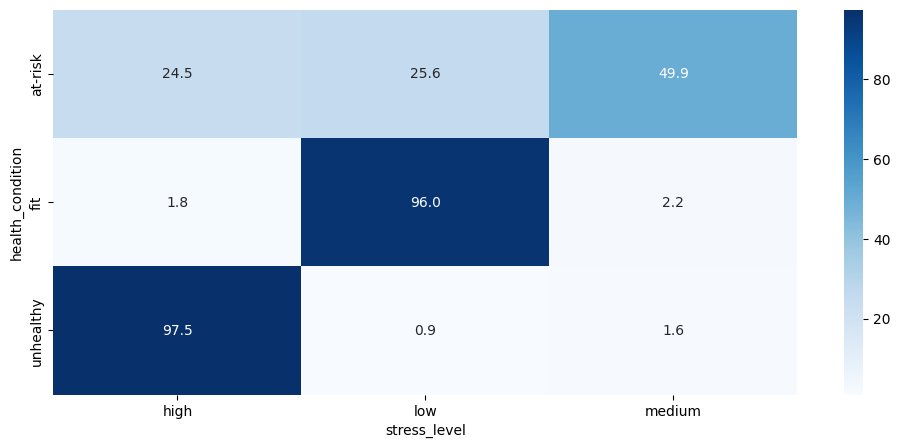

In [72]:
cat_vs_cat('health_condition','stress_level')

- The unhealthy group is overwhelmingly associated with high stress levels, with 97.5% of unhealthy individuals reporting high stress, while less than 2% fall into the low or medium stress categories.
- The fit group is predominantly characterized by low stress levels, with 95.9% of fit individuals having low stress, whereas only 1.8% experience high stress.
- Nearly half (49.9%) of the at-risk individuals have medium stress levels, while the remaining population is almost evenly split between high (24.5%) and low (25.6%) stress levels.
- The clear separation of stress levels across the three health conditions suggests that stress_level is one of the strongest predictors of health_condition in the dataset.

Health Condition vs Sleep quality

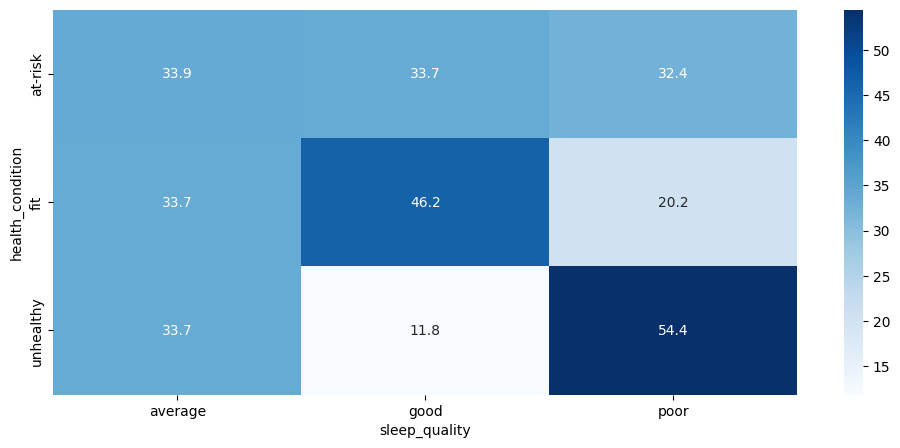

In [73]:
cat_vs_cat('health_condition','sleep_quality')

- The fit group is strongly associated with good sleep quality, with 46.4% of fit individuals reporting good sleep quality, compared to only 20.0% reporting poor sleep quality.
- More than half (54.8%) of the unhealthy group has poor sleep quality, while only 11.6% report good sleep quality, indicating a strong association between poor sleep quality and poor health.
- The at-risk group exhibits an almost uniform distribution across average (34.0%), good (33.8%), and poor (32.2%) sleep quality, suggesting that this group represents an intermediate health state.
- Overall, sleep quality demonstrates a clear relationship with health condition, with good sleep quality being more prevalent among fit individuals and poor sleep quality being dominant among unhealthy individuals, making it a potentially important predictor of health condition.

Health Condition vs Physical Activity Level

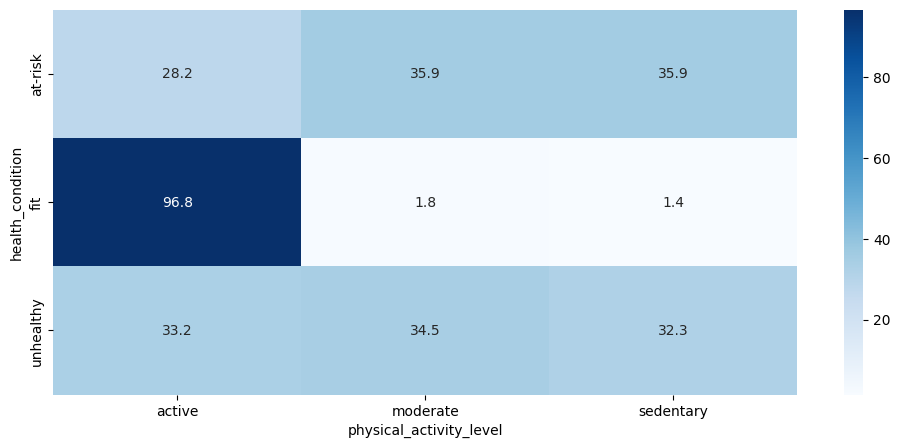

In [74]:
cat_vs_cat('health_condition','physical_activity_level')

- The fit group is overwhelmingly associated with an active lifestyle, with 96.9% of fit individuals classified as physically active, while only 1.7% and 1.4% fall into the moderate and sedentary categories, respectively.
- Overall, physical activity level shows a strong association with health condition, with active individuals being predominantly classified as fit, making this feature a potentially important predictor of health condition.

Health Condition vs Smoking Alcohol

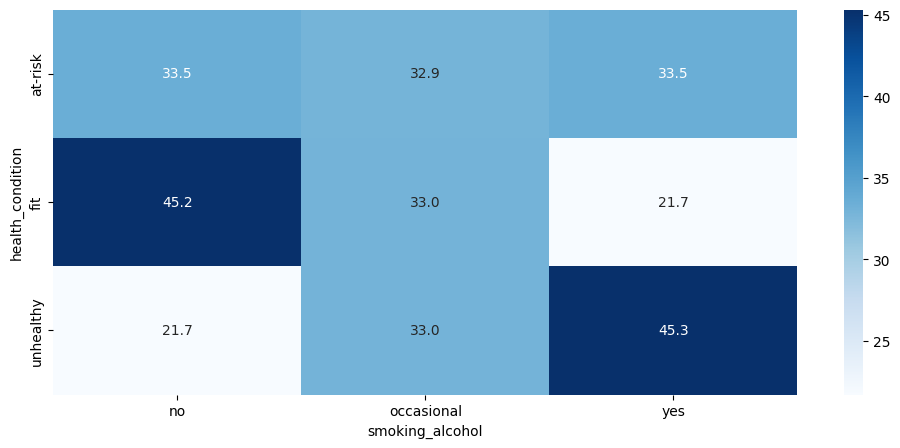

In [75]:
cat_vs_cat('health_condition','smoking_alcohol')

Smoking/alcohol consumption demonstrates a clear association with health condition, with non-smokers being more likely to belong to the fit group and regular smokers/drinkers being more likely to belong to the unhealthy group, making this feature a potentially important predictor of health condition.

Health Condition vs Gender

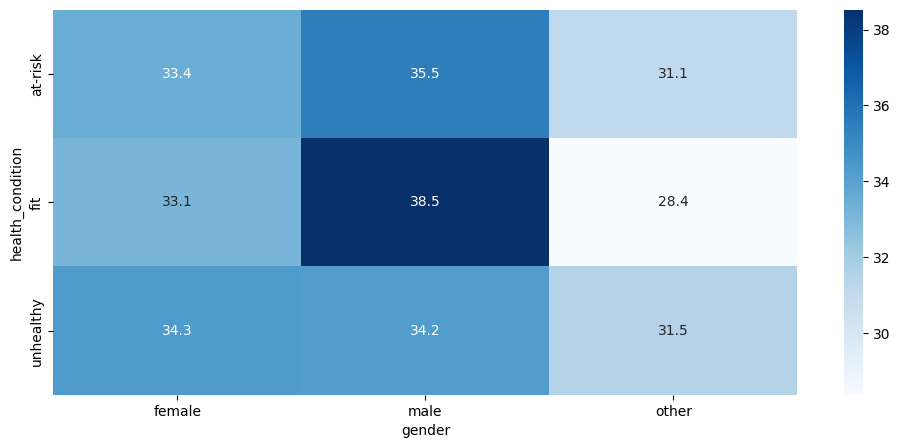

In [76]:
cat_vs_cat('health_condition','gender')

Unlike features such as stress_level, sleep_quality, and smoking_alcohol, the gender feature does not exhibit a strong relationship with health_condition, indicating limited predictive power when considered independently.

## Feature Ranking from EDA

| Feature                 | Relationship with Target |
| ----------------------- | :----------------------: |
| Stress Level            |           ⭐⭐⭐⭐⭐          |
| Sleep Quality           |           ⭐⭐⭐⭐⭐          |
| Physical Activity Level |           ⭐⭐⭐⭐⭐          |
| Step Count              |           ⭐⭐⭐⭐☆          |
| Exercise Duration       |           ⭐⭐⭐⭐☆          |
| Smoking/Alcohol         |           ⭐⭐⭐⭐☆          |
| Calorie Expenditure     |           ⭐⭐⭐⭐☆          |
| BMI                     |           ⭐⭐⭐☆☆          |
| Sleep Duration          |           ⭐⭐⭐☆☆          |
| Heart Rate              |           ⭐☆☆☆☆          |
| Water Intake            |           ⭐☆☆☆☆          |
| Diet Type               |           ⭐☆☆☆☆          |
| Gender                  |           ⭐☆☆☆☆          |

> **Note:** This ranking is based solely on exploratory data analysis and visual inspection. The actual predictive importance of features will be validated during the model-building stage using feature importance and model evaluation metrics.

## Conclusion
The exploratory analysis reveals that lifestyle-related factors such as stress level, sleep quality, physical activity, exercise duration, step count, calorie expenditure, and smoking/alcohol habits exhibit the strongest relationship with health condition. In contrast, demographic factors such as gender and dietary preference show relatively weak associations. These findings provide valuable guidance for feature selection during model development

# Next Steps

The next notebook will include

• Missing value treatment

• Feature engineering

• Encoding

• Feature selection

• Model building

• Cross validation

• Ensemble learning